# Yeast cVAE Training
### GENKI: Generative ENsemble KPI-Informed kinetic modeling
**Xenios et al. (2025)**

This notebook trains the conditional VAE (cVAE) on ORACLE-generated
*S. cerevisiae* kinetic parameter sets for the nanoaerobic steady-state,
then generates a new ensemble conditioned on low zeta-score KPI.

The generated Km sets are used to simulate the
**nanoaerobic → microaerobic** transition (8 simultaneous enzyme perturbations,
Section 3.2) and to reproduce Figure 9.

| Item | Value |
|------|-------|
| Organism | *S. cerevisiae* (yeast) |
| Model | `nanoaerobic1_kinetic.yml` |
| Km parameters | 1 055 |
| KPI threshold | best 5 % by zeta-score KPI |
| Temperatures | 1.0, 2.0, 5.0 (mixed) |
| Output | `outputs/yeast_cvae_km.csv` |

**Environment:** `env_genki_ml` (no skimpy required).


## Setup

In [1]:
import sys
import os

# Add ml4parameters to path (contains cvae/, utils/ modules)
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "ml4parameters"))
sys.path.insert(0, "../ml4parameters")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from utils.env import reset_environment
from utils.preprocessing import preprocess_multilabel_dfs
from utils.plots import plot_vae_training, plot_total_loss
from cvae.encoder import build_conditional_encoder
from cvae.decoder import build_conditional_decoder
from cvae.vae_model import ConditionalVAE, EpochSetter

os.makedirs("../outputs", exist_ok=True)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.16.2


In [2]:
def generate_conditioned(decoder, latent_dim, y_cond, n=2000, temperature=1.0):
    """Sample n Km vectors from the decoder conditioned on y_cond."""
    y_cond = tf.convert_to_tensor(y_cond, dtype=tf.float32)
    if len(y_cond.shape) == 1:
        y_cond = tf.repeat(y_cond[None, :], repeats=n, axis=0)
    z = temperature * tf.random.normal((tf.shape(y_cond)[0], latent_dim))
    return decoder([z, y_cond], training=False)


def postprocess_generated(x_gen, scaler, feature_names, eps=1e-8):
    """Inverse log-StandardScaler → physical Km values (mM)."""
    if hasattr(x_gen, "numpy"):
        x_gen = x_gen.numpy()
    x_up = scaler.inverse_transform(x_gen)
    x_real = np.exp(x_up) - eps
    return pd.DataFrame(x_real, columns=feature_names)


## Configuration

In [3]:
# ── Paper constants (Section 3.2) ─────────────────────────────────────────
KPI_THRESHOLD_PCT = 5        # best 5 % of ORACLE models (zeta-score KPI)
N_GENERATE_EACH   = 2000     # per temperature; three temperatures → 6000 total

# Training data — ORACLE yeast ensemble with zeta-score KPI
DATA_PATH_YEAST = "../data/data_for_training_yeast/yeast_oracle_single_zeta.csv"

# Column names for generated output (Km parameters from ORACLE reference)
KM_REFERENCE_PATH = "../data/ORACLE_sample_9.csv"

# cVAE architecture (Section 2.1, yeast — larger model than E. coli)
LATENT_DIM    = 60
HIDDEN_ENC    = [512, 256]
HIDDEN_DEC    = [256, 512]
BATCH_SIZE    = 150
EPOCHS        = 180
LEARNING_RATE = 1e-3
BETA          = 0.5
MAX_BETA      = 1.5
WARMUP_EPOCHS = 100

# Latent temperatures for generation (Section 3.2)
# Multiple temperatures are used to diversify the generated ensemble
TEMPERATURES  = [1.0, 2.0, 5.0]
# ─────────────────────────────────────────────────────────────────────────


## Load and preprocess training data

In [4]:
df_oracle = pd.read_csv(DATA_PATH_YEAST, index_col=0)
print(f"ORACLE yeast ensemble: {df_oracle.shape[0]} models, "
      f"{df_oracle.shape[1]} columns")
df_oracle.head(3)


ORACLE yeast ensemble: 800 models, 1061 columns


,km_substrate_2DDA7Ptm,km_product_2DDA7Ptm,km_substrate_2OBUTtm,km_product_2OBUTtm,km_substrate1_2OXOADPTm,km_product1_2OXOADPTm,km_substrate2_2OXOADPTm,km_product2_2OXOADPTm,km_substrate_2PGt6,km_product_2PGt6,...,km_substrate2_r_4235,km_product2_r_4235,km_substrate_ru5p2tp,km_product_ru5p2tp,ZSCORE_GLCt1,ZSCORE_LMPD_s_0450_c_1_256,ZSCORE_ETOHt,ZSCORE_CO2t,ZSCORE_OTHER,KPI
1,0.004310,52.734490,3158.158150,0.398367,2.345679,0.006700,19.165775,1966.016268,249.662667,15677.38016,...,6252.441097,9045.746543,1.865488,35128.70299,11.145055,2.419876,6.773865,4.839622,5.992745,31.171163
2,503.945627,169.573617,67.718659,1.086440,3.391342,0.000945,5.689000,45.892719,8589.061940,2732.28723,...,466.107483,19631.801360,2.030075,50785.57743,14.656497,3.223387,9.316248,6.355813,6.858341,40.410287
5,4.905809,3029.732166,1136.712547,4.551601,0.116431,0.001103,8.240549,60.699686,629.642705,30329.89174,...,0.648418,153576.595300,5.573194,166278.19290,10.765182,2.513307,6.627454,4.654905,5.945358,30.506206


In [5]:
# Identify metric columns (KPI and per-reaction zeta-scores)
metric_cols = [c for c in df_oracle.columns if c.startswith("ZSCORE") or c == "KPI"]
print(f"Metric columns ({len(metric_cols)}): {metric_cols}")

# Keep only KPI as the training error signal
def select_metric(df, metric, metric_cols):
    base_cols = [c for c in df.columns if c not in metric_cols]
    out = df[base_cols + [metric]].copy()
    out = out.rename(columns={metric: "Error"})
    return out

df_kpi = select_metric(df_oracle, "KPI", metric_cols)
print(f"\nKPI range: [{df_kpi['Error'].min():.4f}, {df_kpi['Error'].max():.4f}]")
print(f"Km parameters: {df_kpi.shape[1] - 1}")


Metric columns (6): ['ZSCORE_GLCt1', 'ZSCORE_LMPD_s_0450_c_1_256', 'ZSCORE_ETOHt', 'ZSCORE_CO2t', 'ZSCORE_OTHER', 'KPI']

KPI range: [24.7786, 1853856.8612]
Km parameters: 1055


In [6]:
prep = preprocess_multilabel_dfs(
    df_list=[df_kpi],
    percentile_cutoffs=KPI_THRESHOLD_PCT,
)

X_scaled = prep["X_log_standard"]   # log-standardised Km matrix
y_bin    = prep["y_multilabel"]     # shape (n, 1); 1 = in best KPI_THRESHOLD_PCT%

label_dim = y_bin.shape[1]
input_dim = X_scaled.shape[1]

n_pos = y_bin.sum()
print(f"Training samples : {len(X_scaled)}")
print(f"Km parameters    : {input_dim}")
print(f"Class-1 (good)   : {n_pos} ({100*n_pos/len(X_scaled):.1f} %)")
print(f"KPI threshold    : {prep['thresholds'][0]:.6f}  "
      f"(≤ {KPI_THRESHOLD_PCT}th percentile)")



Thresholds per label:
----------------------------------------
Label 0: Error ≤ 29.986163  (percentile 5.0)
----------------------------------------
Training samples : 800
Km parameters    : 1055
Class-1 (good)   : 40 (5.0 %)
KPI threshold    : 29.986163  (≤ 5th percentile)


## Build and train cVAE

In [8]:
reset_environment()

encoder = build_conditional_encoder(
    input_dim=input_dim, label_dim=label_dim, latent_dim=LATENT_DIM,
    hidden_layers=HIDDEN_ENC, activation="elu", use_label_embedding=True,
)
decoder = build_conditional_decoder(
    input_dim=input_dim, label_dim=label_dim, latent_dim=LATENT_DIM,
    hidden_layers=HIDDEN_DEC, activation="gelu", output_activation=None,
    use_label_embedding=True,
)
model = ConditionalVAE(
    encoder=encoder, decoder=decoder,
    beta=BETA, max_beta=MAX_BETA,
    warmup_epochs=WARMUP_EPOCHS, recon_loss="mse",
)
model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))

print(f"Encoder parameters : {encoder.count_params():,}")
print(f"Decoder parameters : {decoder.count_params():,}")
print(f"Latent dim         : {LATENT_DIM}")
print(f"Input dim (Km)     : {input_dim}")


[Environment reset] random seed = 42
Encoder parameters : 719,288
Decoder parameters : 696,671
Latent dim         : 60
Input dim (Km)     : 1055


In [9]:
history = model.fit(
    x=(X_scaled, y_bin),
    y=X_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[EpochSetter()],
)


Epoch 1/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - beta: 0.5000 - kl: 44.7087 - loss: 1085.3805 - recon: 1063.0261
Epoch 2/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - beta: 0.5100 - kl: 38.2885 - loss: 1006.3302 - recon: 986.8030
Epoch 3/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - beta: 0.5200 - kl: 40.9456 - loss: 938.6823 - recon: 917.3906
Epoch 4/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - beta: 0.5300 - kl: 43.9109 - loss: 906.9519 - recon: 883.6791
Epoch 5/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - beta: 0.5400 - kl: 50.3735 - loss: 866.7896 - recon: 839.5879
Epoch 6/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - beta: 0.5500 - kl: 65.1001 - loss: 839.3202 - recon: 803.5153
Epoch 7/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - beta: 0.5600 - kl: 74.7163 - loss: 784.5524 - recon: 742.7112
Epoch 8/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - beta: 0.5700 - kl: 80.5032 - loss: 739.3715 - recon: 693.4846
Epoch 9/180
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - beta: 0.5800 - kl: 87.1276 - loss

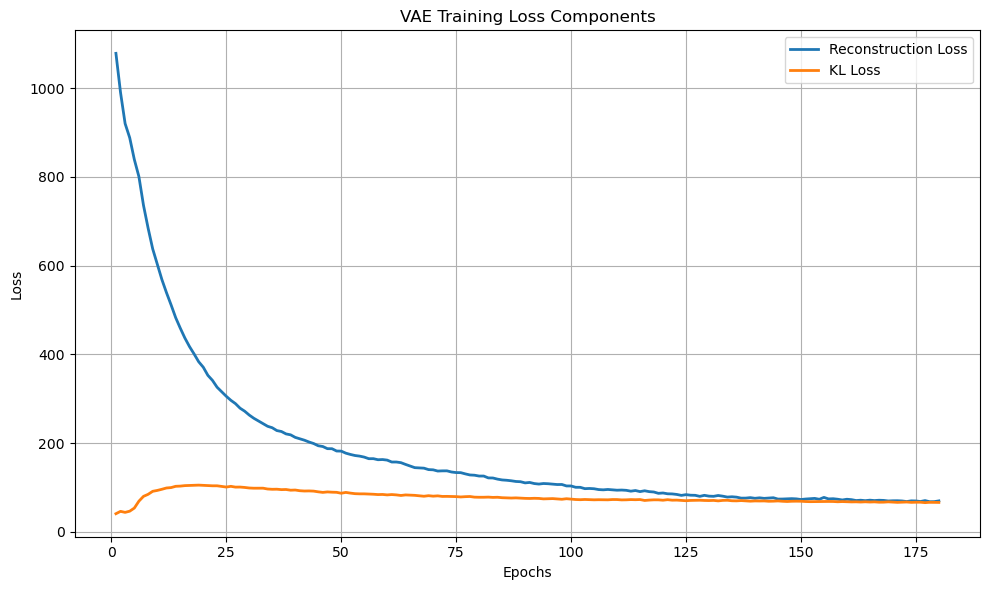

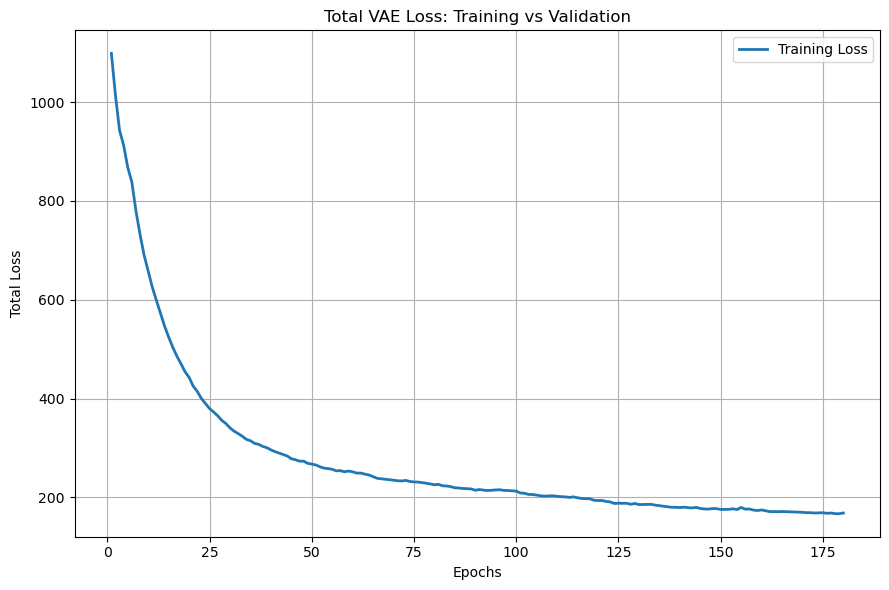

In [10]:
plot_vae_training(history)
plot_total_loss(history)


## Generate Km parameter sets

Three temperatures are used to create a diverse ensemble:
- **T = 1.0** — tight around the class-1 manifold
- **T = 2.0** — moderate diversity
- **T = 5.0** — broad exploration of parameter space

All generated sets are concatenated and filtered for physicality (Km > 0).


In [11]:
# Load Km column names from the ORACLE reference file
km_ref = pd.read_csv(KM_REFERENCE_PATH, index_col=0)
km_cols = km_ref.columns
print(f"Km columns from reference: {len(km_cols)}")


Km columns from reference: 1055


In [12]:
y_target = tf.constant([1.0], dtype=tf.float32)
gen_batches = []

for T in TEMPERATURES:
    x_gen = generate_conditioned(
        decoder, LATENT_DIM, y_target,
        n=N_GENERATE_EACH, temperature=T,
    )
    df_t = postprocess_generated(
        x_gen,
        scaler=prep["scalers"]["log_standard"],
        feature_names=km_cols,
    )
    valid = df_t[(df_t > 0).all(axis=1)]
    gen_batches.append(valid)
    print(f"T={T:.1f}: {len(valid)}/{N_GENERATE_EACH} valid samples")

df_gen = pd.concat(gen_batches, ignore_index=True)
print(f"\nTotal generated: {len(df_gen)} valid Km sets")


T=1.0: 2000/2000 valid samples
T=2.0: 2000/2000 valid samples
T=5.0: 1369/2000 valid samples

Total generated: 5369 valid Km sets


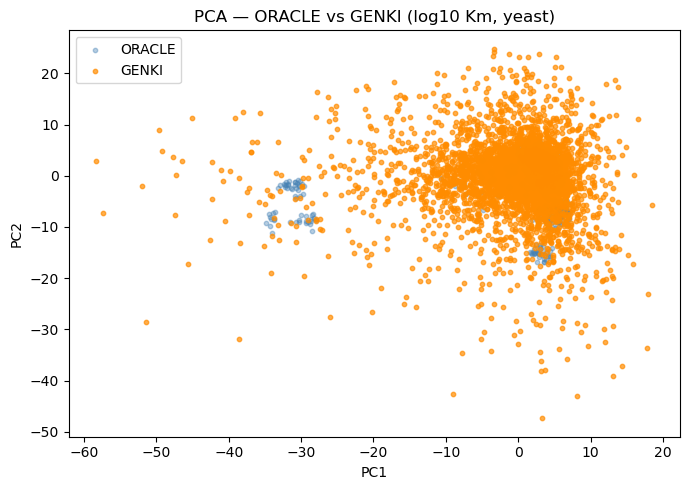

In [13]:
# Quick PCA comparison: generated vs ORACLE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SKStdScaler

common_cols = df_gen.columns.intersection(
    df_oracle.drop(columns=metric_cols, errors="ignore").columns
)

df_oracle_km = df_oracle[common_cols].dropna()
df_gen_km    = df_gen[common_cols].dropna()

# Log10-transform for PCA
df_oracle_log = np.log10(df_oracle_km[(df_oracle_km > 0).all(axis=1)])
df_gen_log    = np.log10(df_gen_km[(df_gen_km > 0).all(axis=1)])

X_all = np.vstack([df_oracle_log.values, df_gen_log.values])
labels = ["ORACLE"] * len(df_oracle_log) + ["GENKI"] * len(df_gen_log)

scaler_pca = SKStdScaler()
X_pca = PCA(n_components=2).fit_transform(scaler_pca.fit_transform(X_all))

fig, ax = plt.subplots(figsize=(7, 5))
for name, color, alpha in [("ORACLE", "steelblue", 0.4), ("GENKI", "darkorange", 0.7)]:
    idx = [i for i, l in enumerate(labels) if l == name]
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], s=10, alpha=alpha, label=name, color=color)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — ORACLE vs GENKI (log10 Km, yeast)")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
# Save to outputs/ — used by scripts/reproduce_fig9_yeast.py
out_path = "../outputs/yeast_cvae_km.csv"
df_gen.to_csv(out_path)
print(f"Saved → {out_path}  ({df_gen.shape})")
print("\n✓ Yeast Km file exported: outputs/yeast_cvae_km.csv")


Saved → ../outputs/yeast_cvae_km.csv  ((5369, 1055))

✓ Yeast Km file exported: outputs/yeast_cvae_km.csv
